In [73]:
# IMPORTS
from memo import memo
from math import exp
import jax
import numpy as np
import jax.numpy as jnp
from jax.scipy.stats import beta as jax_beta
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'config'))
from ceride_palettes import PALETTES, PLOT_THEME

# GLOBALS
INFO, ACTION = 0, 1
CAN, IMP, NULL = 0, 1, 2
ACT, PASS = 0, 1
goals = [INFO, ACTION]
U = [CAN, IMP, NULL]
R = [ACT, PASS]

delta = 0.7  # face-threat cost of IMP (flat — the act of commanding, not its outcome)

mu_vals    = np.linspace(0.001, .999, 50)   # grid over ability
theta_vals = np.linspace(0.01, 0.99, 20)    # ability threshold grid
v_vals     = np.linspace(0.01, 0.99, 20)    # grid over willingness
phi_vals   = np.linspace(0.01, 0.99, 10)    # willingness threshold grid
f_k   = 10   # concentration of feasibility/willingness priors
alpha = 10   # softmax param

# CONTEXTS: (f_ctx, w_ctx) — ability × willingness
contexts = {
    'run a marathon':  (0.10, 0.01), # low ability, low willingness
    'benchpress 150':   (0.10, 0.90), # low ability, high willingness
    'give me $50':    (0.80, 0.20), # moderate ability, low willingness
    'drive me home':    (0.70, 0.80), # moderate ability, high willingness
    'call me later':    (0.90, 0.80), # high ability, high willingness
    'pass the salt':    (0.99, 0.99), # high ability, high willingness
}
ctx_sorted = sorted(contexts.items(), key=lambda kv: kv[1][0] * kv[1][1])  # sort by f×w

In [74]:
## Primitives

# Goal prior: action goals presuppose both ability and willingness
# Given both, max-entropy → P(action) = 0.5 * f_ctx * w_ctx
@jax.jit
def goal_prior(g, f_ctx, w_ctx):
    p_action = 0.5 * f_ctx * w_ctx
    return jnp.where(g == ACTION, p_action, 1 - p_action)

# Feasibility prior: Beta prior over mu, concentrated around f_ctx
def f_prior(mu, f_ctx):
    mu_c = jnp.clip(mu, .01, .99)
    return jax_beta.pdf(mu_c, f_ctx * f_k, (1 - f_ctx) * f_k)

# Willingness prior: same structure as f_prior
def v_prior(v, w_ctx):
    v_c = jnp.clip(v, .01, .99)
    return jax_beta.pdf(v_c, w_ctx * f_k, (1 - w_ctx) * f_k)

# Information gain: MI between mu and the answer to "can you?" (mu > t)
@jax.jit
def discrete_entropy(probs):
    p_c = jnp.clip(probs, 1e-12, 1.0)
    return -jnp.sum(p_c * jnp.log(p_c))

@jax.jit
def info_gain(f_ctx, t):
    mu_arr = jnp.array(mu_vals)
    raw = jax_beta.pdf(jnp.clip(mu_arr, .01, .99), f_ctx * f_k, (1 - f_ctx) * f_k)
    pi_f = raw / jnp.sum(raw)
    p_y = jnp.where(mu_arr > t, 1.0, 0.0)
    p_yes_marg = jnp.sum(pi_f * p_y)
    p_no_marg = 1.0 - p_yes_marg
    post_yes = pi_f * p_y / jnp.clip(p_yes_marg, 1e-12)
    post_no  = pi_f * (1 - p_y) / jnp.clip(p_no_marg, 1e-12)
    return discrete_entropy(pi_f) - p_yes_marg * discrete_entropy(post_yes) \
                                  - p_no_marg  * discrete_entropy(post_no)

# Response: ACT entails YES (acting demonstrates both ability and willingness)
# EU(ACT) = comply (ability AND willingness), EU(PASS) = 1 - P(g=action)
@jax.jit
def respond(mu, t, v, phi, p_ga):
    """P(ACT | mu, t, v, phi, goal posterior)"""
    comply = jnp.where(mu > t, 1.0, 0.0) * jnp.where(v > phi, 1.0, 0.0)
    logits = alpha * jnp.array([comply, 1.0 - p_ga])
    logits = logits - logits.max()
    p = jnp.exp(logits)
    return p[ACT] / p.sum()

def marginalize_response(f_ctx, w_ctx, p_ga):
    """P(ACT) marginalized over mu (Beta), theta (uniform), v (Beta), phi (uniform)"""
    mu_arr = jnp.array(mu_vals)
    v_arr  = jnp.array(v_vals)
    raw_mu = jax_beta.pdf(jnp.clip(mu_arr, .01, .99), f_ctx * f_k, (1 - f_ctx) * f_k)
    w_mu   = raw_mu / jnp.sum(raw_mu)
    raw_v  = jax_beta.pdf(jnp.clip(v_arr,  .01, .99), w_ctx * f_k, (1 - w_ctx) * f_k)
    w_v    = raw_v  / jnp.sum(raw_v)
    total = 0.0
    for t in theta_vals:
        for phi in phi_vals:
            acts = jax.vmap(lambda mu: jax.vmap(lambda v: respond(mu, t, v, phi, p_ga))(v_arr))(mu_arr)
            total += float(jnp.einsum('ij,i,j->', acts, w_mu, w_v))
    return total / (len(theta_vals) * len(phi_vals))

print("IG by context (avg over theta):")
for label, (f_ctx, w_ctx) in ctx_sorted:
    igs = [float(info_gain(f_ctx, t)) for t in theta_vals]
    print(f"  {label:<18} f={f_ctx:.2f} w={w_ctx:.2f}  avg_IG={np.mean(igs):.4f}")

IG by context (avg over theta):
  run a marathon     f=0.10 w=0.01  avg_IG=0.1505
  benchpress 150     f=0.10 w=0.90  avg_IG=0.1505
  give me $50        f=0.80 w=0.20  avg_IG=0.2042
  drive me home      f=0.70 w=0.80  avg_IG=0.2391
  call me later      f=0.90 w=0.80  avg_IG=0.1505
  pass the salt      f=0.99 w=0.99  avg_IG=0.0818


In [75]:
## S1 — speaker marginalizes over addressee's ability and willingness
# Speaker knows their goal g but not addressee's mu or v
# given(mu, t, v, phi) + wants/EU → softmax of expected utility
u_label    = {CAN: 'can', IMP: 'imp', NULL: 'null'}
goal_label = {INFO: 'info', ACTION: 'action'}

@jax.jit
def eu_s1(u, g, mu, t, v, phi, f_ctx):
    comply = jnp.where(mu > t, 1.0, 0.0) * jnp.where(v > phi, 1.0, 0.0)  # ability AND willingness
    act    = jnp.where(u == IMP, comply, 0.)
    info   = jnp.where(u == CAN, info_gain(f_ctx, t), 0.)
    social = jnp.where(u == IMP, delta, 0.)
    return jnp.where(g == ACTION, act, info) - social

@memo
def S1[_u: U, _g: goals](f_ctx, w_ctx, alpha):
    speaker: knows(_g)
    speaker: given(mu in mu_vals, wpp=f_prior(mu, f_ctx))
    speaker: given(t in theta_vals, wpp=1)
    speaker: given(v in v_vals, wpp=v_prior(v, w_ctx))
    speaker: given(phi in phi_vals, wpp=1)
    speaker: wants(payoff = eu_s1(u, _g, mu, t, v, phi, f_ctx))
    speaker: chooses(u in U, wpp=exp(alpha * EU[payoff]))
    return Pr[speaker.u == _u]

s1_out = S1(f_ctx=0.5, w_ctx=0.7, alpha=alpha)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s1_out[ui, gi]), 3) for ui, u in enumerate(U)}
    print(f"S1(g={goal_label[g]}) = {probs}")

S1(g=info) = {'can': 0.784, 'imp': 0.0, 'null': 0.216}
S1(g=action) = {'can': 0.342, 'imp': 0.316, 'null': 0.342}


In [76]:
## A1 — addressee infers goal, then responds
# A1_goal references S1 directly — only 6 inner states (g × u)
# Response computed externally (addressee knows their own mu and v)

@memo
def A1_goal[_g: goals](f_ctx, w_ctx, alpha):
    a1: knows(_g)
    a1: thinks[
        spk: given(g in goals, wpp=goal_prior(g, f_ctx, w_ctx)),
        spk: chooses(u in U, wpp=S1[u, g](f_ctx, w_ctx, alpha))
    ]
    a1: observes_that[spk.u == 0] # conditioning on u = CAN
    return a1[Pr[spk.g == _g]]

def a1_act(f_ctx, w_ctx):
    """A1's aggregate compliance: goal inference + response, marginalized"""
    p_ga = float(A1_goal(f_ctx=f_ctx, w_ctx=w_ctx, alpha=alpha)[ACTION])
    return marginalize_response(f_ctx, w_ctx, p_ga)

print("A1 by context:")
for label, (f_ctx, w_ctx) in ctx_sorted:
    g1   = float(A1_goal(f_ctx=f_ctx, w_ctx=w_ctx, alpha=alpha)[ACTION])
    p_a1 = a1_act(f_ctx, w_ctx)
    print(f"  {label:<18} f={f_ctx:.2f} w={w_ctx:.2f}  P(g=act)={g1:.3f}  P(act)={p_a1:.3f}")

A1 by context:
  run a marathon     f=0.10 w=0.01  P(g=act)=0.000  P(act)=0.001
  benchpress 150     f=0.10 w=0.90  P(g=act)=0.031  P(act)=0.053
  give me $50        f=0.80 w=0.20  P(g=act)=0.048  P(act)=0.103
  drive me home      f=0.70 w=0.80  P(g=act)=0.114  P(act)=0.415
  call me later      f=0.90 w=0.80  P(g=act)=0.131  P(act)=0.554
  pass the salt      f=0.99 w=0.99  P(g=act)=0.149  P(act)=0.702


In [77]:
## S2 — speaker anticipates A1's aggregate compliance

@jax.jit
def eu_s2(u, g, mu, t, v, phi, f_ctx, p_a1_do):
    """S2 utility: CAN+ACTION uses A1's aggregate compliance"""
    comply  = jnp.where(mu > t, 1.0, 0.0) * jnp.where(v > phi, 1.0, 0.0)
    act_can = jnp.where(u == CAN, p_a1_do, 0.)
    act_imp = jnp.where(u == IMP, comply, 0.)
    act     = jnp.where(u == CAN, act_can, act_imp)
    info    = jnp.where(u == CAN, info_gain(f_ctx, t), 0.)
    social  = jnp.where(u == IMP, delta, 0.)
    return jnp.where(g == ACTION, act, info) - social

@memo
def S2[_u: U, _g: goals](f_ctx, w_ctx, p_a1_do, alpha):
    speaker: knows(_g)
    speaker: given(mu in mu_vals, wpp=f_prior(mu, f_ctx))
    speaker: given(t in theta_vals, wpp=1)
    speaker: given(v in v_vals, wpp=v_prior(v, w_ctx))
    speaker: given(phi in phi_vals, wpp=1)
    speaker: wants(payoff = eu_s2(u, _g, mu, t, v, phi, f_ctx, p_a1_do))
    speaker: chooses(u in U, wpp=exp(alpha * EU[payoff]))
    return Pr[speaker.u == _u]

p_a1_mid = a1_act(0.5, 0.7)
s2_out = S2(f_ctx=0.5, w_ctx=0.7, p_a1_do=p_a1_mid, alpha=alpha)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s2_out[ui, gi]), 3) for ui, u in enumerate(U)}
    print(f"S2(g={goal_label[g]}) = {probs}")

S2(g=info) = {'can': 0.784, 'imp': 0.0, 'null': 0.216}
S2(g=action) = {'can': 0.721, 'imp': 0.215, 'null': 0.064}


In [78]:
## A2 — same structure as A1, but models S2

@memo
def A2_goal[_g: goals](f_ctx, w_ctx, p_a1_do, alpha):
    a2: knows(_g)
    a2: thinks[
        spk: given(g in goals, wpp=goal_prior(g, f_ctx, w_ctx)),
        spk: chooses(u in U, wpp=S2[u, g](f_ctx, w_ctx, p_a1_do, alpha))
    ]
    a2: observes_that[spk.u == 0]
    return a2[Pr[spk.g == _g]]

def a2_act(f_ctx, w_ctx):
    """A2's aggregate compliance"""
    p_a1 = a1_act(f_ctx, w_ctx)
    p_ga = float(A2_goal(f_ctx=f_ctx, w_ctx=w_ctx, p_a1_do=p_a1, alpha=alpha)[ACTION])
    return marginalize_response(f_ctx, w_ctx, p_ga)

print("A2 by context:")
for label, (f_ctx, w_ctx) in ctx_sorted:
    p_a1 = a1_act(f_ctx, w_ctx)
    g2   = float(A2_goal(f_ctx=f_ctx, w_ctx=w_ctx, p_a1_do=p_a1, alpha=alpha)[ACTION])
    p_a2 = a2_act(f_ctx, w_ctx)
    print(f"  {label:<18} f={f_ctx:.2f} w={w_ctx:.2f}  P(g=act)={g2:.3f}  P(act)={p_a2:.3f}")

A2 by context:
  run a marathon     f=0.10 w=0.01  P(g=act)=0.000  P(act)=0.001
  benchpress 150     f=0.10 w=0.90  P(g=act)=0.039  P(act)=0.055
  give me $50        f=0.80 w=0.20  P(g=act)=0.070  P(act)=0.111
  drive me home      f=0.70 w=0.80  P(g=act)=0.306  P(act)=0.524
  call me later      f=0.90 w=0.80  P(g=act)=0.441  P(act)=0.696
  pass the salt      f=0.99 w=0.99  P(g=act)=0.613  P(act)=0.862


context               f    w  P(g=a|A1)  P(act|A1)  P(g=a|A2)  P(act|A2)
  run a marathon     0.10 0.01     0.0004      0.001     0.0004      0.001
  benchpress 150     0.10 0.90     0.0311      0.053     0.0389      0.055
  give me $50        0.80 0.20     0.0483      0.103     0.0705      0.111
  drive me home      0.70 0.80     0.1144      0.415     0.3060      0.524
  call me later      0.90 0.80     0.1307      0.554     0.4412      0.696
  pass the salt      0.99 0.99     0.1485      0.702     0.6127      0.862

A1 goal mono:       True
A2 goal mono:       True
A1 compliance mono: True
A2 compliance mono: True


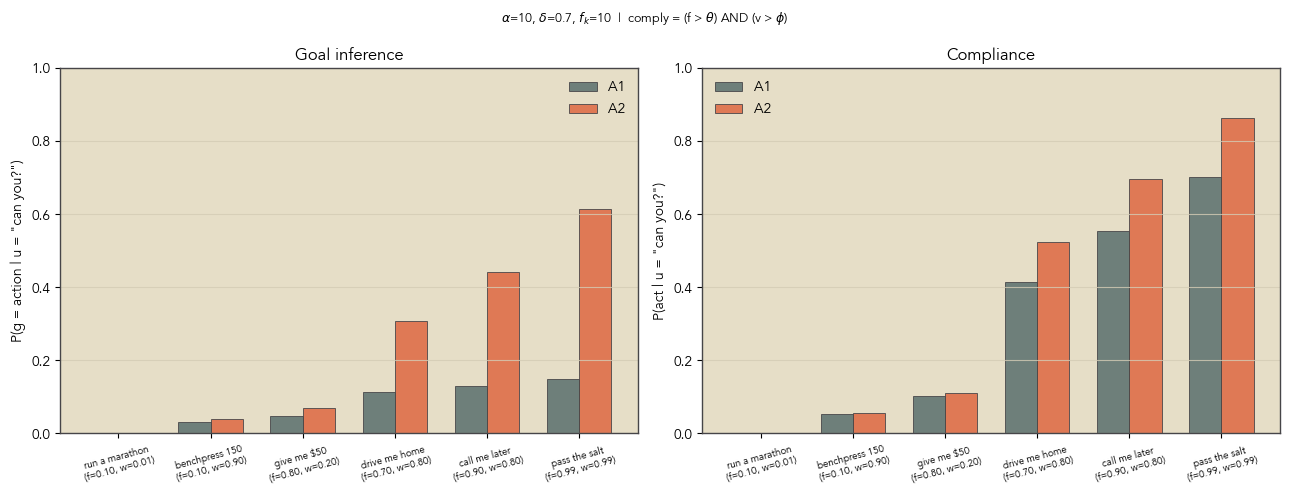

In [79]:
## plots: goal inference + compliance

plt.rcParams.update(PLOT_THEME)
c_a1 = PALETTES['primary'][1]
c_a2 = PALETTES['primary'][3]
c_ig = PALETTES['primary'][0]

out_dir = os.path.join(os.path.dirname('__file__'), '..', 'results', 'whyask')

ga1 = [float(A1_goal(f_ctx=f, w_ctx=w, alpha=alpha)[ACTION]) for _, (f, w) in ctx_sorted]
ga2 = [float(A2_goal(f_ctx=f, w_ctx=w, p_a1_do=a1_act(f, w), alpha=alpha)[ACTION]) for _, (f, w) in ctx_sorted]
va1 = [a1_act(f, w) for _, (f, w) in ctx_sorted]
va2 = [a2_act(f, w) for _, (f, w) in ctx_sorted]

print(f"{'context':<18} {'f':>4} {'w':>4} {'P(g=a|A1)':>10} {'P(act|A1)':>10} {'P(g=a|A2)':>10} {'P(act|A2)':>10}")
for (label, (f_ctx, w_ctx)), g1, p_a1, g2, p_a2 in zip(ctx_sorted, ga1, va1, ga2, va2):
    print(f"  {label:<18} {f_ctx:>4.2f} {w_ctx:>4.2f} {g1:>10.4f} {p_a1:>10.3f} {g2:>10.4f} {p_a2:>10.3f}")
print(f"\nA1 goal mono:       {all(a < b for a, b in zip(ga1, ga1[1:]))}")
print(f"A2 goal mono:       {all(a < b for a, b in zip(ga2, ga2[1:]))}")
print(f"A1 compliance mono: {all(a < b for a, b in zip(va1, va1[1:]))}")
print(f"A2 compliance mono: {all(a < b for a, b in zip(va2, va2[1:]))}")

x       = np.arange(len(ctx_sorted))
x_ticks = [f"{l}\n(f={f:.2f}, w={w:.2f})" for l, (f, w) in ctx_sorted]
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.bar(x - width/2, ga1, width, color=c_a1, alpha=0.85, edgecolor='#464548', linewidth=0.7, label='A1')
ax.bar(x + width/2, ga2, width, color=c_a2, alpha=0.85, edgecolor='#464548', linewidth=0.7, label='A2')
ax.set_xticks(x); ax.set_xticklabels(x_ticks, fontsize=7, rotation=15, ha='center')
ax.set_ylabel('P(g = action | u = "can you?")')
ax.set_title('Goal inference'); ax.set_ylim(0, 1); ax.legend()
ax = axes[1]
ax.bar(x - width/2, va1, width, color=c_a1, alpha=0.85, edgecolor='#464548', linewidth=0.7, label='A1')
ax.bar(x + width/2, va2, width, color=c_a2, alpha=0.85, edgecolor='#464548', linewidth=0.7, label='A2')
ax.set_xticks(x); ax.set_xticklabels(x_ticks, fontsize=7, rotation=15, ha='center')
ax.set_ylabel('P(act | u = "can you?")')
ax.set_title('Compliance'); ax.set_ylim(0, 1); ax.legend()
plt.suptitle(fr'$\alpha$={alpha}, $\delta$={delta}, $f_k$={f_k}  |  comply = (f > $\theta$) AND (v > $\phi$)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'goal_compliance.png'), dpi=150, bbox_inches='tight')
plt.show()

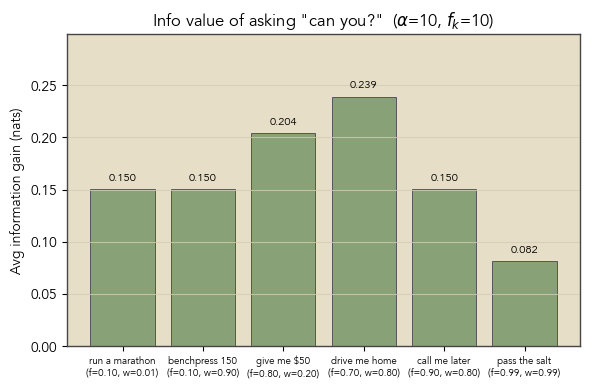

In [80]:
## plots: information gain

ig_vals = []
for label, (f_ctx, w_ctx) in ctx_sorted:
    igs = [float(info_gain(f_ctx, t)) for t in theta_vals]
    ig_vals.append(np.mean(igs))
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(x, ig_vals, color=c_ig, alpha=0.85, edgecolor='#464548', linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(x_ticks, fontsize=7)
ax.set_ylabel('Avg information gain (nats)')
ax.set_title(fr'Info value of asking "can you?"  ($\alpha$={alpha}, $f_k$={f_k})')
ax.set_ylim(0, max(ig_vals) * 1.25)
for bar, v in zip(bars, ig_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'info_gain.png'), dpi=150, bbox_inches='tight')
plt.show()